,Farm A,Farm B,Farm C
Metric,,,
Accuracy,98.8%,86.2%,69.8%
Precision,98.5%,83.3%,67.9%
Recall,99.0%,92.5%,73.3%
Separation (anomaly vs normal),92.6pp,39.1pp,9.5pp
Earliest detection,48h,47h,67h
Primary fault type,Hydraulic/gearbox,Bearing damage,Mixed electrical/mechanical


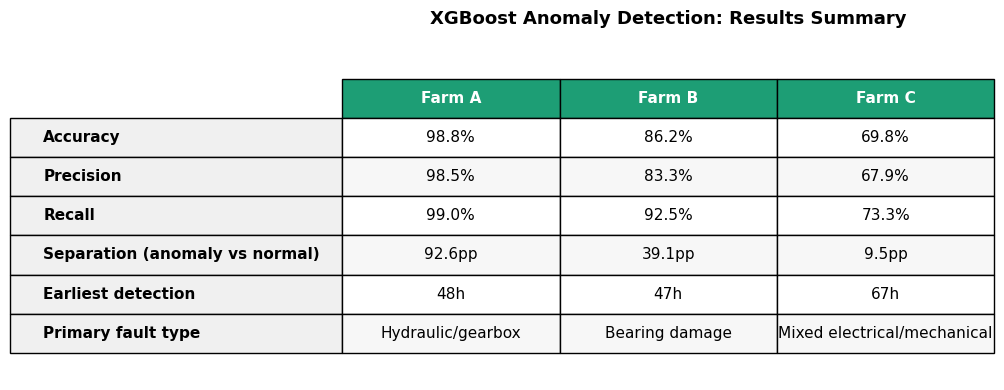

Table saved as results_summary_table.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Final results table — all numbers confirmed from model runs
results = {
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Separation (anomaly vs normal)",
        "Earliest detection",
        "Primary fault type"
    ],
    "Farm A": [
        "98.8%",
        "98.5%",
        "99.0%",
        "92.6pp",
        "48h",
        "Hydraulic/gearbox"
    ],
    "Farm B": [
        "86.2%",
        "83.3%",
        "92.5%",
        "39.1pp",
        "47h",
        "Bearing damage"
    ],
    "Farm C": [
        "69.8%",
        "67.9%",
        "73.3%",
        "9.5pp",
        "67h",
        "Mixed electrical/mechanical"
    ]
}

df_results = pd.DataFrame(results).set_index("Metric")

# Display as interactive table in notebook
display(df_results)

# Also save as a clean image for slides
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

table = ax.table(
    cellText  = df_results.values,
    rowLabels = df_results.index,
    colLabels = df_results.columns,
    cellLoc   = "center",
    loc       = "center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 2.2)

# Header row styling
for col_idx in range(len(df_results.columns)):
    table[0, col_idx].set_facecolor("#1D9E75")
    table[0, col_idx].set_text_props(color="white", fontweight="bold")

# Index column styling
for row_idx in range(len(df_results.index)):
    table[row_idx + 1, -1].set_facecolor("#f0f0f0")
    table[row_idx + 1, -1].set_text_props(fontweight="bold")

# Alternating row colours
for row_idx in range(len(df_results.index)):
    for col_idx in range(len(df_results.columns)):
        if row_idx % 2 == 0:
            table[row_idx + 1, col_idx].set_facecolor("#ffffff")
        else:
            table[row_idx + 1, col_idx].set_facecolor("#f7f7f7")

plt.title("XGBoost Anomaly Detection: Results Summary",
          fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("results_summary_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("Table saved as results_summary_table.png")